# 2 april: TOZ differentiaalvergelijkingen met SymPy

Gegeven is de volgende constructie:

```{figure-start} ./opgave2_data/constructie.svg
:align: center
:source: https://github.com/Structural-Mechanics-CEG/mechanics-figures-source/tree/main/sympy_5
:number:
```

$$EI\left(x\right) = 64000 \, \rm{kNm}^2$$

```{figure-end}
```

Vind de maximale waarde van het moment en de verplaatsing op $x=3$ en $x=3.3$. Bekijk je eigen indiening in [WebLab](https://weblab.tudelft.nl/ctb1310/2025-2026/assignment/166889/info). Heb je nog geen toegang? Schrijf je dan eerst [hier](https://weblab.tudelft.nl/ctb1310/2025-2026/enroll) in voor dit vak op WebLab.

::::{admonition-start} Uitwerking
:class: solution, dropdown
::::

In [3]:
import sympy as sym
sym.init_printing(use_latex='mathjax')
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display as ipy_display, Math

%config InlineBackend.figure_formats = ['svg']

def display(*objs):
    for obj in objs:
        if isinstance(obj, dict):
            lines = [f"{sym.latex(k)} &= {sym.latex(obj[k])}" for k in sorted(obj, key=lambda s: str(s))]
            ipy_display(Math(r"\begin{aligned}" + r"\\ ".join(lines) + r"\end{aligned}"))
        else:
            ipy_display(obj)

def plot(w_list, x_range_list,ylabel):
    fig = plt.figure(facecolor='none')
    for i, w in enumerate(w_list):
        # check if x is the only symbol in the expression
        if len(w.free_symbols) > 1:
            raise ValueError('The expression must be a function of x only.')
        
        w_numpy = sym.lambdify(x, w)
        x_vals = np.linspace(x_range_list[i][0], x_range_list[i][1], 100)
        
        # if the expression is a constant, we need to make sure that it is broadcasted correctly
        if isinstance(w_numpy(x_vals),float) or isinstance(w_numpy(x_vals),int):
            w_numpy = np.vectorize(w_numpy)
            plt.plot([x_range_list[i][0], x_range_list[i][1]],[w_numpy(x_vals),w_numpy(x_vals)])
        else:
            plt.plot(x_vals,w_numpy(x_vals))

        plt.xlabel('$x$')
        plt.ylabel(ylabel)
    ax = plt.gca()
    ax.set_facecolor('none')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.invert_yaxis()

In [4]:
import sympy as sym

In [5]:
sym.var('x')
sym.var('C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11, C12');

In [62]:
q = 15
EI = 64000
q1 = 0 
q2 = q
q3 = q

In [63]:
V1 = sym.integrate(-q1,x)+C1
M1 = sym.integrate(V1,x)+C2
kappa1 = M1 / EI
phi1 = sym.integrate(kappa1,x)+C3
w1 = sym.integrate(-phi1,x)+C4

V2 = sym.integrate(-q2,x)+C5
M2 = sym.integrate(V2,x)+C6
kappa2 = M2 / EI
phi2 = sym.integrate(kappa2,x)+C7
w2 = sym.integrate(-phi2,x)+C8

V3 = sym.integrate(-q3,x)+C9
M3 = sym.integrate(V3,x)+C10
kappa3 = M3 / EI
phi3 = sym.integrate(kappa3,x)+C11
w3 = sym.integrate(-phi3,x)+C12

In [64]:
L1 = 4
L2 = 5
L3 = 6
F = 15#40

Eq1  = sym.Eq(  w1.subs(x, 0), 0)
Eq2  = sym.Eq(  M1.subs(x, 0), 0)
Eq3  = sym.Eq(  w1.subs(x, L1),   w2.subs(x,L1))
Eq4  = sym.Eq(  M1.subs(x, L1), 0)
Eq5  = sym.Eq(  M2.subs(x, L1), 0)
Eq6  = sym.Eq( -V1.subs(x, L1)+ F + V2.subs(x, L1), 0)
Eq7  = sym.Eq(  w2.subs(x, L1 + L2), 0)
Eq8  = sym.Eq(  w3.subs(x, L1 + L2), 0)
Eq9  = sym.Eq(  M2.subs(x, L1+L2),   M3.subs(x, L1 + L2))
Eq10 = sym.Eq(phi2.subs(x, L1+L2), phi3.subs(x, L1 + L2))
Eq11 = sym.Eq(  w3.subs(x, L1 + L2 + L3), 0)
Eq12 = sym.Eq(  M3.subs(x, L1 + L2 + L3), 0)

In [65]:
sol = sym.solve((Eq1, Eq2, Eq3, Eq4, Eq5, Eq6, Eq7, Eq8, Eq9, Eq10, Eq11, Eq12), (C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11, C12))
display(sol)

<IPython.core.display.Math object>

In [70]:
w1_oplossing = w1.subs(sol)
w2_oplossing = w2.subs(sol)
w3_oplossing = w3.subs(sol)
phi1_oplossing = phi1.subs(sol)
phi2_oplossing = phi2.subs(sol)
phi3_oplossing = phi3.subs(sol)
M1_oplossing = M1.subs(sol)
M2_oplossing = M2.subs(sol)
M3_oplossing = M3.subs(sol)

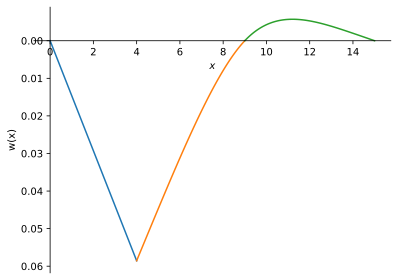

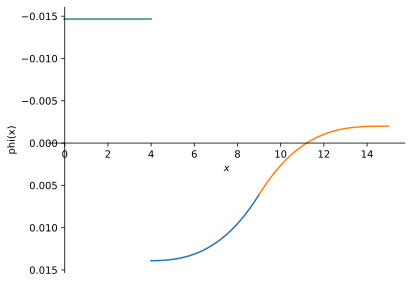

In [72]:
plot([w1_oplossing, w2_oplossing, w3_oplossing], [(0, L1), (L1, L1+L2), (L1+L2, L1+L2+L3)], 'w(x)')
plot([phi1_oplossing, phi2_oplossing, phi3_oplossing], [(0, L1), (L1, L1+L2), (L1+L2, L1+L2+L3)], 'phi(x)')


In [78]:
eq13 = sym.Eq(phi3_oplossing, 0)
x_max_w = sym.solve(eq13, x)[2]
display(x_max_w)
display(x_max_w.evalf())
max_w = w3_oplossing.subs(x, x_max_w)
display(max_w)
display(max_w.evalf())

      ___________________                                   
     ╱ 9⋅√374561   44065                                    
  3 ╱  ───────── + ─────                                    
  ╲╱       8        64                  1                179
- ─────────────────────── - ────────────────────────── + ───
             3                     ___________________   12 
                                  ╱ 9⋅√374561   44065       
                            48⋅3 ╱  ───────── + ─────       
                               ╲╱       8        64         

11.2063362480989

                                                                             3 ↪
               ⎛      ___________________                                   ⎞  ↪
               ⎜     ╱ 9⋅√374561   44065                                    ⎟  ↪
               ⎜  3 ╱  ───────── + ─────                                    ⎟  ↪
               ⎜  ╲╱       8        64                  1                179⎟  ↪
           179⋅⎜- ─────────────────────── - ────────────────────────── + ───⎟  ↪
               ⎜             3                     ___________________   12 ⎟  ↪
               ⎜                                  ╱ 9⋅√374561   44065       ⎟  ↪
               ⎜                            48⋅3 ╱  ───────── + ─────       ⎟  ↪
  594143       ⎝                               ╲╱       8        64         ⎠  ↪
- ────── - ─────────────────────────────────────────────────────────────────── ↪
  409600                                 307200                                ↪
                            

-0.00571269907198566

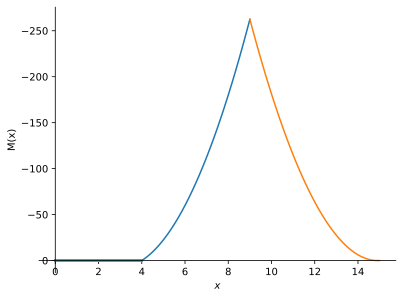

In [69]:
plot([M1_oplossing, M2_oplossing, M3_oplossing], [(0, L1), (L1, L1+L2), (L1+L2, L1+L2+L3)], 'M(x)')

In [ ]:
w1_3 = w1_oplossing.subs(x,3)*1000 # mm
w1_right_of_3 = w1_oplossing.subs(x,3.3)*1000 #mm

display(w1_3)
display(w1_3.evalf())
display(w1_right_of_3)
display(w1_right_of_3.evalf())

        2                
  1215⋅ℯ    6075   6075⋅ℯ
- ─────── - ──── + ──────
     8       8       8   

182.607368460995

                             2
1419.91056562844 - 167.0625⋅ℯ 

185.476381100843

::::{admonition-end}
::::